In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.datasets.mnist import load_data

In [ ]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
X_train = np.expand_dims(X_train, axis=-1)

In [ ]:
X_test = np.expand_dims(X_test, axis=-1)

In [ ]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (5, 5), padding='valid', activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Conv2D(64, (5, 5), padding='valid', activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [ ]:
model.fit(x=X_train, y=y_train, epochs=5, batch_size=512, validation_data=(X_test, y_test))

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 495ms/step - accuracy: 0.8167 - loss: 2.7311 - val_accuracy: 0.9668 - val_loss: 0.1095
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 484ms/step - accuracy: 0.9640 - loss: 0.1144 - val_accuracy: 0.9809 - val_loss: 0.0659
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 467ms/step - accuracy: 0.9780 - loss: 0.0708 - val_accuracy: 0.9836 - val_loss: 0.0512
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 83s 476ms/step - accuracy: 0.9839 - loss: 0.0506 - val_accuracy: 0.9848 - val_loss: 0.0476
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 81s 473ms/step - accuracy: 0.9883 - loss: 0.0373 - val_accuracy: 0.9861 - val_loss: 0.0423


In [ ]:
test_image = X_test[0].reshape(1, 28, 28, 1).astype(np.float32)

In [ ]:
test_image.shape

(1, 28, 28, 1)

In [ ]:
layer_outputs = []
for layer in model.layers:
  temp_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=layer.output)
  pred = temp_model.predict(test_image)
  layer_outputs.append(pred)

  print(f"Layer: {layer.name} Output shape: {pred.shape}")
  print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Layer: conv2d Output shape: (1, 24, 24, 32)
[[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  ...

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Layer: flatten Output shape: (1, 1024)
[[0. 0. 0. ... 0. 0. 0.]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Layer: dense Output shape: (1, 256)
[[ 0.          6.244494    8.365037    0.          0.          0.15089093
   0.61515343  0.          0.          0.          0.          0.87247604
  10.34633     0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          2.2497349   0.          0.          0.
   0.          0.          0.          0.5789895   0.          0.
   0.          0.          0.          0.          0.          0.
   3.8515637   3.7405784   0.          0.          0.          0.
   0.          0.          3.6387563   0.          0.          0.
   0.          0.          1.7730657   0.87875134  0.          0.
   0.          0.         12.398002    0.          0.          3.7168818
   3.9209993   0.          4.1417685   0.          2.4865658   0.
   0.          0.          0.24668172  0.    

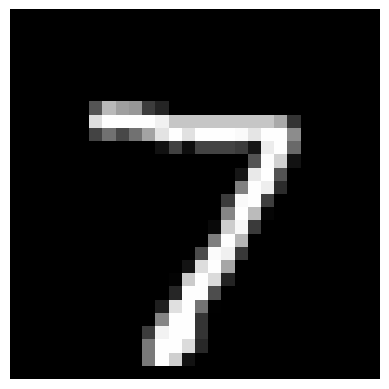

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(test_image.reshape(28, 28), cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
np.argmax(pred)

np.int64(7)

In [ ]:
layer_outputs[0][0].shape

(24, 24, 32)

In [ ]:
kernel = model.get_layer('conv2d').get_weights()[0]

In [ ]:
kernel.shape

(5, 5, 1, 32)

In [ ]:
kernel[:, :, 0, 1]

array([[ 0.02513412,  0.05923296,  0.02040382, -0.03296023,  0.02973365],
       [ 0.00398097, -0.0597166 ,  0.04636386,  0.0394302 ,  0.05877417],
       [-0.09479203, -0.0356206 ,  0.02180088, -0.03526653,  0.00507895],
       [ 0.00221169, -0.10167175, -0.10990594, -0.0819231 , -0.03674151],
       [ 0.00977585,  0.04482888,  0.01190819, -0.04199857,  0.03547745]],
      dtype=float32)

## Object detection

In [ ]:
!pip install -U ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import matplotlib.patches as patches
from PIL import Image

# Load a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")


0: 512x640 1 person, 3 dogs, 164.0ms
Speed: 2.7ms preprocess, 164.0ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)


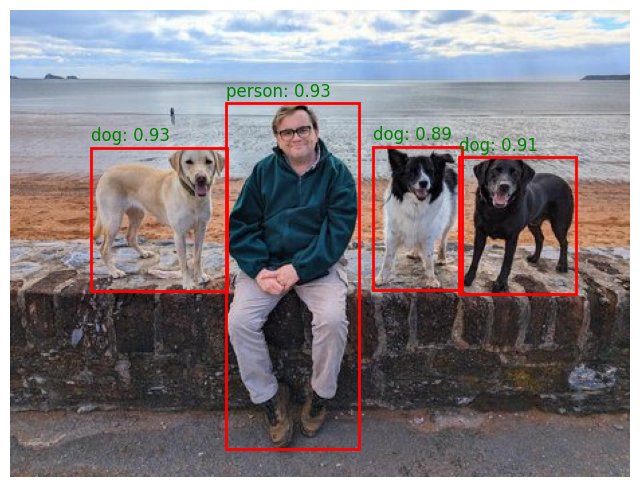

In [ ]:
image_path = 'course_example.jpeg'
image = Image.open(image_path).convert('RGB')

results = model.predict(image)

boxes = results[0].boxes.xyxy  # Bounding box coordinates
scores = results[0].boxes.conf # Confidence scores
labels = results[0].boxes.cls # Confidence scores

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(image)

# Draw bounding boxes
for box, score, label in zip(boxes, scores, labels):
  x_min, y_min, x_max, y_max = box.tolist()
  width, height = x_max - x_min, y_max - y_min
  rec = patches.Rectangle((x_min, y_min), width, height, edgecolor='red', linewidth=2, facecolor="none")
  ax.add_patch(rec)
  ax.text(x_min, y_min - 5, f"{model.names[int(label)]}: {score:.2f}", color="green", fontsize=12)

plt.axis("off")
plt.show()